## Imports

In [66]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

## Processing a single ecg signal.

In [69]:
import wfdb

record = wfdb.rdrecord('mitdb_full/100', sampfrom=0, sampto=2000)
signal = record.p_signal

In [70]:
lead = signal[:, 0]

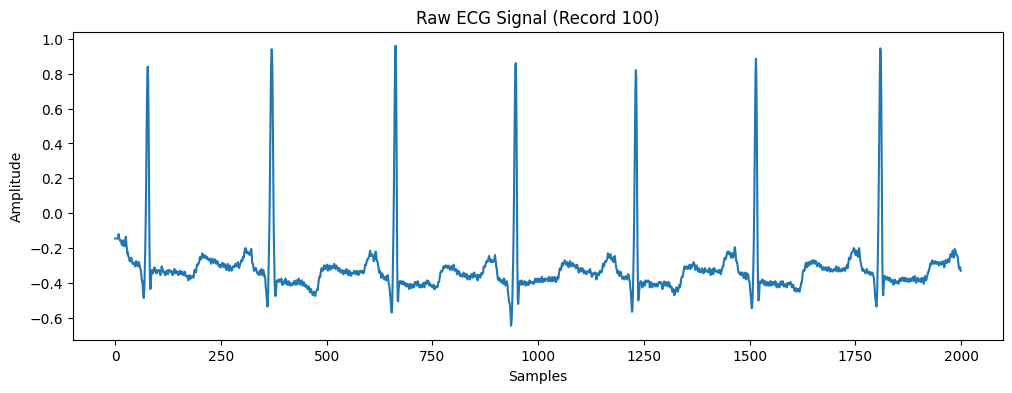

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(lead)
plt.title("Raw ECG Signal (Record 100)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

## Filtering High Freequency noise

In [72]:
import numpy as np
from scipy.signal import butter, filtfilt

fs = 360  # sampling frequency

def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    
    return filtered

In [73]:
filtered_signal = bandpass_filter(lead, 0.5, 40, fs)

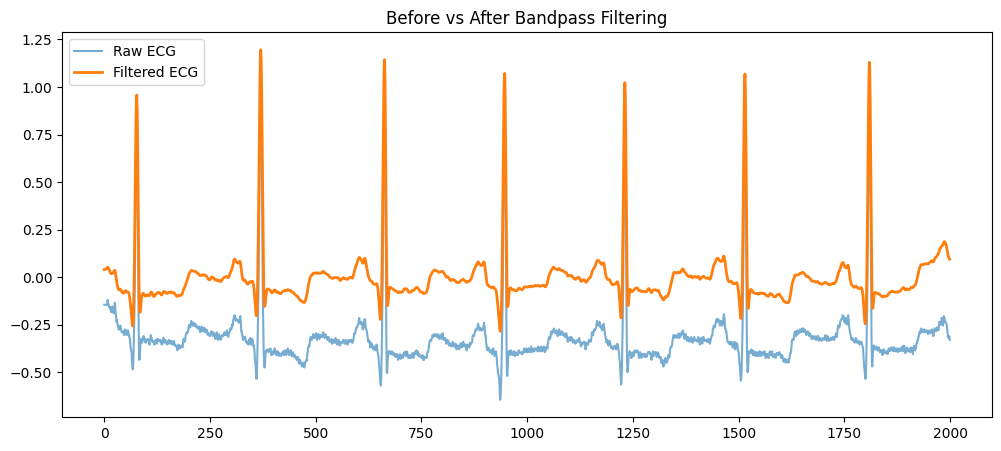

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(lead, label="Raw ECG", alpha=0.6)
plt.plot(filtered_signal, label="Filtered ECG", linewidth=2)
plt.legend()
plt.title("Before vs After Bandpass Filtering")
plt.show()

## Finding the R wave peaks

In [75]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(filtered_signal, distance=150, height=0.5)

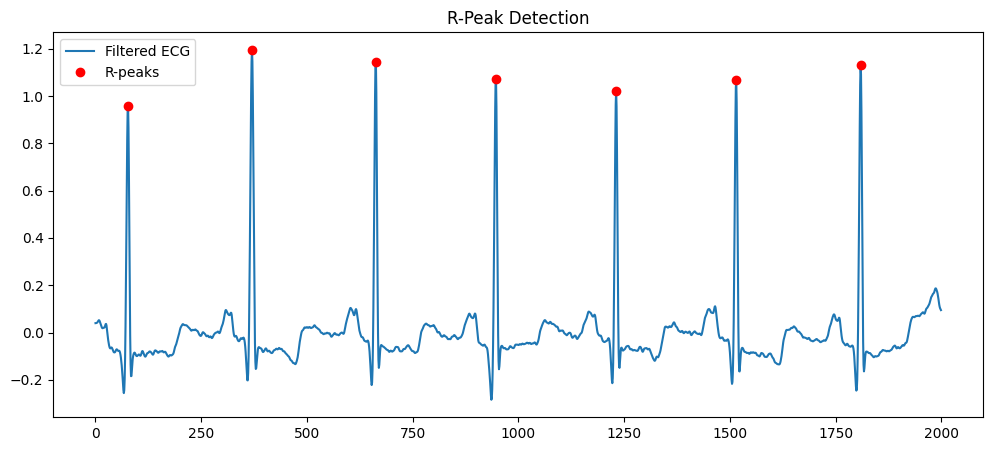

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(filtered_signal, label="Filtered ECG")
plt.plot(peaks, filtered_signal[peaks], "ro", label="R-peaks")
plt.legend()
plt.title("R-Peak Detection")
plt.show()

In [77]:
import numpy as np

rr_intervals = np.diff(peaks) / fs
heart_rate = 60 / np.mean(rr_intervals)

print("Heart Rate:", heart_rate, "BPM")

Heart Rate: 74.82678983833719 BPM


## Validation of detected picks by atr files

In [78]:
annotation = wfdb.rdann('mitdb_full/100', 'atr', sampfrom=0, sampto=2000)

true_peaks = annotation.sample

In [79]:
tolerance = 20  # samples (~50 ms)

correct = 0

for tp in true_peaks:
    if any(abs(tp - p) < tolerance for p in peaks):
        correct += 1

accuracy = correct / len(true_peaks)

print("Accuracy:", accuracy)

Accuracy: 0.875


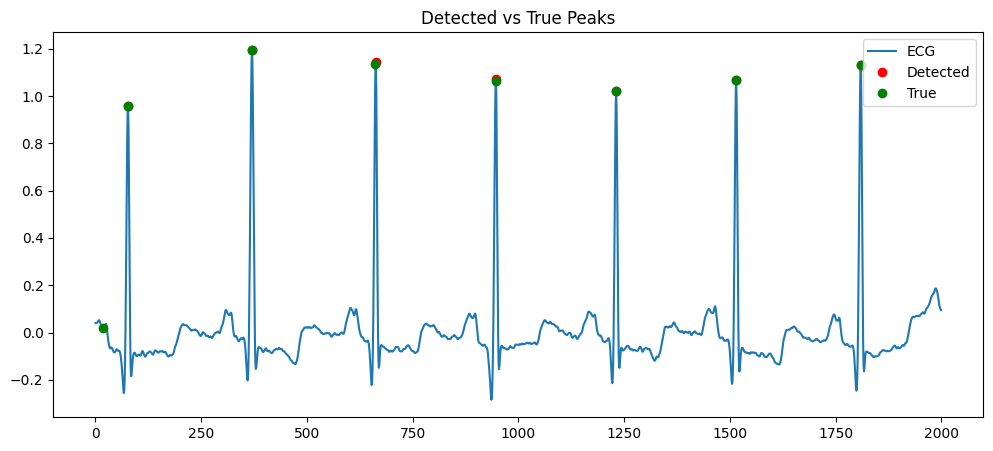

In [81]:
plt.figure(figsize=(12,5))
plt.plot(filtered_signal, label="ECG")

plt.plot(peaks, filtered_signal[peaks], "ro", label="Detected")
plt.plot(true_peaks, filtered_signal[true_peaks], "go", label="True")

plt.legend()
plt.title("Detected vs True Peaks")
plt.show()

# Implementing ML

### Feature Extraction Function

In [82]:
def extract_features_segments(record_name):
    record = wfdb.rdrecord(f'mitdb_full/{record_name}')
    annotation = wfdb.rdann(f'mitdb_full/{record_name}', 'atr')

    signal = record.p_signal[:, 0]
    fs = 360

    # Filter
    filtered = bandpass_filter(signal, 0.5, 40, fs)

    # Detect peaks
    peaks, _ = find_peaks(filtered, distance=150, height=0.5)

    features_list = []
    labels_list = []

    # Use sliding window
    window_size = 2000  # ~5 sec

    for start in range(0, len(filtered) - window_size, window_size):
        segment = filtered[start:start + window_size]

        # Peaks in this segment
        seg_peaks = [p for p in peaks if start <= p < start + window_size]
        seg_peaks = np.array(seg_peaks) - start

        if len(seg_peaks) < 2:
            continue

        # RR intervals
        rr_intervals = np.diff(seg_peaks) / fs

        # Features
        heart_rate = 60 / np.mean(rr_intervals)
        rr_mean = np.mean(rr_intervals)
        rr_std = np.std(rr_intervals)
        signal_mean = np.mean(segment)
        signal_std = np.std(segment)

        # Label from annotations
        seg_ann = [annotation.symbol[i] for i, s in enumerate(annotation.sample)
                   if start <= s < start + window_size]

        abnormal_beats = sum(1 for s in seg_ann if s != 'N')
        abnormal_ratio = abnormal_beats / len(seg_ann) if len(seg_ann) > 0 else 0

        label = 1 if abnormal_ratio > 0.1 else 0

        features_list.append([heart_rate, rr_mean, rr_std, signal_mean, signal_std])
        labels_list.append(label)

    return features_list, labels_list

In [83]:
features, label = extract_features('100')
print(features, label)

[np.float64(73.99563998754283), np.float64(0.8108585858585858), np.float64(0.04856413620818394), np.float64(-5.585622580693199e-05), np.float64(0.2063175688442837)] 0


## Create Dataset

In [95]:
records = [str(i) for i in range(100, 110)]  # 10 records (can increase)
print(records)
X = []
y = []

for r in records:
    f, l = extract_features_segments(r)
    X.extend(f)
    y.extend(l)

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))
print("Class distribution:", np.bincount(y))

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']
Total samples: 3146
Class distribution: [1472 1674]


## Model Training

In [96]:
from sklearn.ensemble import RandomForestClassifier

# Create model
final_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train on FULL dataset
final_model.fit(X, y)

print("✅ Final model trained on full dataset")

✅ Final model trained on full dataset


In [97]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [98]:
def predict_ecg(record_name):
    features, actual_label = extract_features(record_name)

    prediction = final_model.predict([features])[0]

    result = "Abnormal" if prediction == 1 else "Normal"
    actual = "Abnormal" if actual_label == 1 else "Normal"

    return features, result, actual

In [99]:
def compute_severity(heart_rate, rr_std, abnormal_ratio):
    score = (
        abs(heart_rate - 75)/75 +
        rr_std +
        abnormal_ratio
    )

    if score < 0.3:
        return "Normal"
    elif score < 0.6:
        return "Mild"
    elif score < 0.8:
        return "Moderate"
    else:
        return "Severe"

In [100]:
features, prediction, actual = predict_ecg('105')

# You can compute abnormal ratio separately if needed
severity = compute_severity(
    features[0],  # heart rate
    features[2],  # rr std
    0.2           # placeholder (can improve later)
)

print("🔍 Prediction:", prediction)
print("📊 Actual:", actual)
print("⚠️ Severity:", severity)

🔍 Prediction: Abnormal
📊 Actual: Normal
⚠️ Severity: Mild


## Testing accuracy of model

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [161]:
# =========================
# IMPORTS
# =========================
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================
# BANDPASS FILTER
# =========================
def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# =========================
# FEATURE EXTRACTION (FIXED)
# =========================
def extract_features_segments(record_name):
    record = wfdb.rdrecord(f'mitdb_full/{record_name}')
    annotation = wfdb.rdann(f'mitdb_full/{record_name}', 'atr')

    signal = record.p_signal[:, 0]
    fs = 360

    filtered = bandpass_filter(signal, 0.5, 40, fs)

    peaks, _ = find_peaks(filtered, distance=150, height=0.5)

    features_list = []
    labels_list = []

    window_size = 2000

    for start in range(0, len(filtered) - window_size, window_size):
        segment = filtered[start:start + window_size]

        seg_peaks = [p for p in peaks if start <= p < start + window_size]
        seg_peaks = np.array(seg_peaks) - start

        if len(seg_peaks) < 2:
            continue

        rr_intervals = np.diff(seg_peaks) / fs

        # FEATURES
        heart_rate = 60 / np.mean(rr_intervals)
        rr_mean = np.mean(rr_intervals)
        rr_std = np.std(rr_intervals)
        signal_mean = np.mean(segment)
        signal_std = np.std(segment)
        peak_amplitude = np.max(segment) - np.min(segment)
        signal_energy = np.sum(segment**2) / len(segment)
        peak_count = len(seg_peaks)

        # LABEL (NO LEAKAGE)
        seg_ann = [annotation.symbol[i] for i, s in enumerate(annotation.sample)
                   if start <= s < start + window_size]

        label = 0
        for s in seg_ann:
            if s != 'N':
                label = 1
                break

        features_list.append([
    heart_rate,
    rr_mean,
    rr_std,
    signal_mean,
    signal_std,
    peak_amplitude,
    signal_energy,
    peak_count
])
        labels_list.append(label)

    return features_list, labels_list

# =========================
# RECORD-LEVEL SPLIT
# =========================
train_records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116'
]

test_records = [
    '117','118','119','121','122','123','124'
]

X_train, y_train = [], []
X_test, y_test = [], []

for r in train_records:
    f, l = extract_features_segments(r)
    X_train.extend(f)
    y_train.extend(l)

for r in test_records:
    f, l = extract_features_segments(r)
    X_test.extend(f)
    y_test.extend(l)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("Class distribution (train):", np.bincount(y_train))

# =========================
# TRAIN MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=200,        # more trees → better learning
    max_depth=6,             # prevent overfitting
    min_samples_split=5,     # better generalization
    class_weight='balanced', # VERY IMPORTANT (fix recall)
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# EVALUATE MODEL
# =========================
y_pred = model.predict(X_test)

print("\n=== MODEL PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# =========================
# SEVERITY FUNCTION
# =========================
def compute_severity(heart_rate, rr_std):
    score = abs(heart_rate - 75)/75 + rr_std

    if score < 0.3:
        return "Normal"
    elif score < 0.6:
        return "Mild"
    elif score < 0.8:
        return "Moderate"
    else:
        return "Severe"

# =========================
# FINAL PREDICTION FUNCTION
# =========================
def predict_ecg(record_name):
    f, l = extract_features_segments(record_name)

    if len(f) == 0:
        return "Not enough data"

    f = np.array(f)
    preds = model.predict(f)

    # Final prediction (majority)
    final_pred = int(np.round(np.mean(preds)))

    # 🔥 ACTUAL label (majority from true labels)
    actual = int(np.round(np.mean(l)))

    # Severity
    heart_rate = f[0][0]
    rr_std = f[0][2]
    severity = compute_severity(heart_rate, rr_std)

    return final_pred, actual, severity

# =========================
# TEST FINAL SYSTEM
# =========================
pred, actual, severity = predict_ecg('122')

print("\n=== FINAL RESULT ===")
print("Prediction:", "Abnormal" if pred == 1 else "Normal")
print("Actual:", "Abnormal" if actual == 1 else "Normal")
print("Severity:", severity)

Train samples: 4843
Test samples: 2268
Class distribution (train): [2699 2144]

=== MODEL PERFORMANCE ===
Accuracy: 0.7063492063492064
Precision: 0.6931297709923664
Recall: 0.4940152339499456
F1 Score: 0.576874205844981

=== FINAL RESULT ===
Prediction: Normal
Actual: Normal
Severity: Normal


In [162]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1148  201]
 [ 465  454]]


In [163]:
import joblib

joblib.dump(model, "ecg_model.pkl")
print("Model saved!")

Model saved!


In [164]:
import wfdb

records = ['100','101','103','105','118','122']

for r in records:
    wfdb.dl_database('mitdb', dl_dir='test_data', records=[r])

Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: test_data
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
Generating record list for: 118
Generating list of all files for: 118
Finished downloading files
Generating record list for: 122
Generating list of all files for: 122
Finished downloading files
